In [31]:
#1.CHT & battery capacity

def calculate_CHT_and_charge_capacity(voltage, current, point, target_voltage_start, target_voltage_end):
    crossing_start = False
    crossing_end = False
    start_time = 0
    end_time = 0
    charge_capacity = 0
    
    for i in range(len(voltage)):
        if voltage[i] < target_voltage_start:
            crossing_start = True
            start_time = point[i]
        elif voltage[i] >= target_voltage_start and crossing_start:
            crossing_start = False
        elif voltage[i] >= target_voltage_end:
            crossing_end = True
            end_time = point[i]
            break
    
    if crossing_start or not crossing_end:
        return None, None, None
    
    for i in range(1, len(voltage)):
        if point[i] >= start_time and point[i] <= end_time:
            time_difference = point[i] - point[i - 1]
            charge_capacity += current[i] * time_difference
    
    return end_time - start_time, charge_capacity, end_time


target_voltage_start = 4.0
target_voltage_end = 4.2

cht, charge_capacity, end_time = calculate_CHT_and_charge_capacity(voltage, current, point, target_voltage_start, target_voltage_end)


#2.Qvol
def calculate_voltage_and_capacity(voltage, current, point, end_time):
    voltage_at_current_zero = None
    capacity_change = 0
    
    current_zero_time = None
    for i in range(1, len(current)):
        if current[i-1] > 0 and current[i] == 0:
            current_zero_time = point[i]
            break
    
    if current_zero_time is None:
        return None, None
    
 
    start_index = point.index(end_time)
    end_index = point.index(current_zero_time)
    

    voltage_at_current_zero = voltage[start_index]
    
    for i in range(start_index, end_index + 1):
        if current[i] == 0:
            voltage_at_current_zero = voltage[i]
            break
    

    for i in range(start_index, end_index):
        time_difference = point[i + 1] - point[i]
        capacity_change += current[i] * time_difference
    
    return voltage_at_current_zero, capacity_change

voltage_at_current_zero, capacity_change = calculate_voltage_and_capacity(voltage, current, point, end_time)



#3.放电电压
def calculate_resistance(voltage, current):
    
    start_index = None
    end_index = None
    for i in range(1, len(current)):
        if current[i-1] == 0 and current[i] < 0:
            start_index = i-1
            end_index = i
            break

    if start_index is None or end_index is None:
        return None

    
    delta_voltage = voltage[end_index] - voltage[start_index]
    delta_current = current[end_index] - current[start_index]
    resistance = delta_voltage / delta_current if delta_current != 0 else float('inf')

    return resistance


resistance = calculate_resistance(voltage, current)


#4.
def calculate_voltage_change(voltage, current):
    start_index = None
    end_index = None

    
    for i in range(1, len(current)):
        if current[i-1] > 0 and current[i] == 0:
            start_index = i-1
            end_index = i+10
            break

    if start_index is None or end_index is None:
        return None

    
    voltage_change = abs(voltage[end_index] - voltage[start_index])

    return voltage_change


voltage_change = calculate_voltage_change(voltage, current)






In [47]:
import pandas as pd

file_path = r'/Users/maggiexu/Downloads/Enhui_test2/Aging/145008/145008_AG271-300.xlsx'  
sheet_name = "Channel_1-008"
df = pd.read_excel(file_path, sheet_name=sheet_name)

# 循环遍历每个循环
for i in range(0, 30):
    cycle_data = df[df['Cycle_Index'] == i]
    
    # 提取电压、时间和电流数据
    voltage = cycle_data['Voltage(V)'].tolist()
    point = cycle_data['Data_Point'].tolist()
    current = cycle_data['Current(A)'].tolist()


    # 计算 CHT 和 Charge Capacity
    cht, charge_capacity, end_time = calculate_CHT_and_charge_capacity(voltage, current, point, target_voltage_start, target_voltage_end)

    # 计算 Voltage at Current Zero 和 Capacity Change
    voltage_at_current_zero, capacity_change = calculate_voltage_and_capacity(voltage, current, point, end_time)

    # 计算 Resistance 和 Voltage Change during Current Zero
    resistance = calculate_resistance(voltage, current)
    voltage_change = calculate_voltage_change(voltage, current)

    # 计算 Ratio
    if charge_capacity is not None and capacity_change is not None and capacity_change != 0:
        ratio = charge_capacity / capacity_change
    else:
        ratio = None
        

    # 将结果存储到 DataFrame 中
    result = pd.DataFrame({
        'Cycle_Index': [cycle_data],
        'CHT (seconds)': [cht],
        'Charge Capacity (Ah)': [charge_capacity],
        'Voltage at Current Zero (V)': [voltage_at_current_zero],
        'Capacity Change (Ah)': [capacity_change],
        'Resistance': [resistance],
        'Voltage Change during Current Zero (V)': [voltage_change],
        'Ratio': [ratio]
    }, index=[0])  # 添加索引

    results_df = pd.concat([results_df, result], ignore_index=True)

# 将结果写入到新的 Excel 文件中
results_df.to_excel('/Users/maggiexu/Downloads/Enhui_test2/Aging/145008/cycle_result.xlsx', index=False)


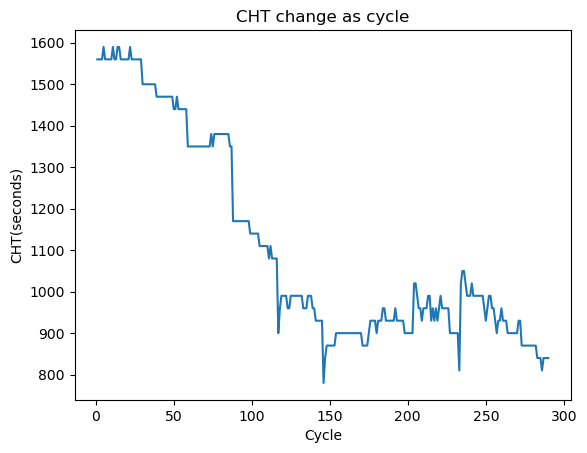

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
file_path = "/Users/maggiexu/Downloads/Enhui_test2/Aging/145007/145007_result.xlsx"
df_result=pd.read_excel(file_path)

#1
x=df_result['Cycle_Index']
y=df_result['CHT (seconds)']

plt.plot(x,y)

plt.title('CHT change as cycle')
plt.xlabel('Cycle')
plt.ylabel('CHT(seconds)')

# 显示图形
plt.show()







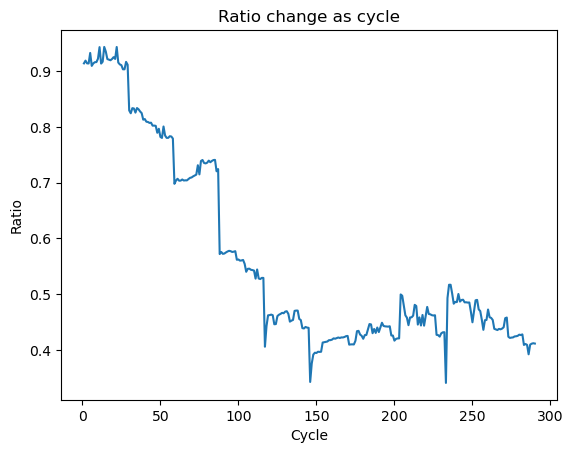

In [3]:
#2
x=df_result['Cycle_Index']
y=df_result['Ratio']

plt.plot(x,y)

plt.title('Ratio change as cycle')
plt.xlabel('Cycle')
plt.ylabel('Ratio')

# 显示图形
plt.show()

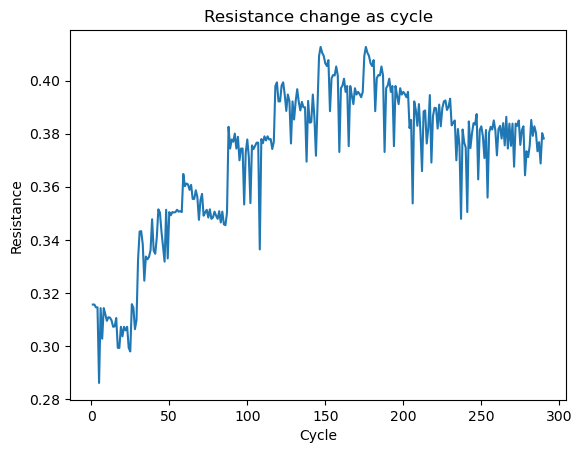

In [210]:
#3
x=df_result['Cycle_Index']
y=df_result['Resistance']

plt.plot(x,y)

plt.title('Resistance change as cycle')
plt.xlabel('Cycle')
plt.ylabel('Resistance')

# 显示图形
plt.show()

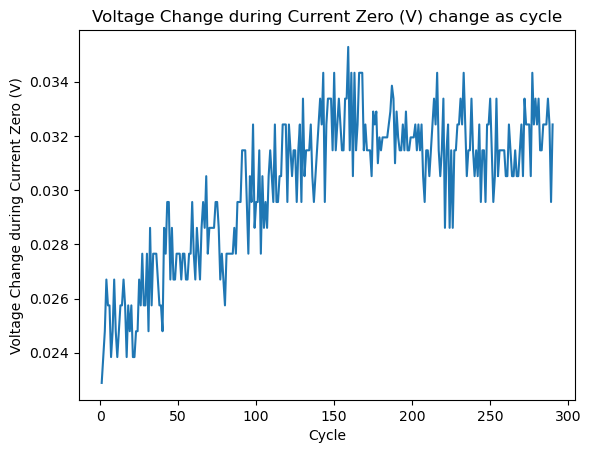

In [4]:
#3
x=df_result['Cycle_Index']
y=df_result['Voltage Change during Current Zero (V)']

plt.plot(x,y)

plt.title('Voltage Change during Current Zero (V) change as cycle')
plt.xlabel('Cycle')
plt.ylabel('Voltage Change during Current Zero (V)')

# 显示图形
plt.show()

In [21]:
import pandas as pd

file_path = r'/Users/maggiexu/Downloads/Enhui_test2/Aging/145007/145007_AG271-300.xlsx'  
sheet_name = "Channel_1-007"
df = pd.read_excel(file_path, sheet_name=sheet_name)

cycle_data = df[df['Cycle_Index']==1]

# 获取电压、数据点和电流列的列表
voltage = cycle_data['Voltage(V)'].tolist()
point = cycle_data['Data_Point'].tolist()
current = cycle_data['Current(A)'].tolist()


def integrate_current():
    # 找到电流变化的开始和结束索引
    start_index = None
    end_index = len(current) - 1 
    for i in range(len(current) - 1):
        if current[i] == 0 and current[i+1] < 0:
            start_index = i
            break

    if start_index is None or end_index is None:
        print("未找到合适的电流变化范围")
        return None
    
    # 初始化容量变化
    capacity_change = 0
    
    # 计算容量变化
    for i in range(start_index, end_index):
        time_difference = point[i + 1] - point[i]
        capacity_change += abs(current[i] * time_difference)
        
    return capacity_change

# 计算电流变化的容量
result = integrate_current()
print("Current capacity:", result)



Current capacity: 76.58148038387299
